**Objective**

Train baseline machine learning models for driver behaviour classification and save predictions and performance metrics for AI Trust Score evaluation.

Input

data/processed/dms_features.csv

Outputs

outputs/
│
├── metrics/
│      baseline_results.csv
│      classification_report.csv
│
├── predictions/
│      random_forest_predictions.csv
│      xgboost_predictions.csv
│      lightgbm_predictions.csv
│
└── figures/
       confusion_matrix_rf.png
       confusion_matrix_xgb.png
       confusion_matrix_lgbm.png

In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    classification_report,

    confusion_matrix

)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt

import seaborn as sns

In [2]:
PROJECT_DIR = Path("/workspaces/DBA-ai-trust-score-framework-Interim")

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

OUTPUT_DIR = PROJECT_DIR / "outputs"

METRICS_DIR = OUTPUT_DIR / "metrics"

PREDICTIONS_DIR = OUTPUT_DIR / "predictions"

FIGURE_DIR = OUTPUT_DIR / "figures"

METRICS_DIR.mkdir(parents=True, exist_ok=True)

PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
DATA = pd.read_csv(

    PROCESSED_DIR /

    "dms_features.csv"

)

print(DATA.shape)

DATA.head()

(1400, 18)


,file_name,label,dataset,original_path,width,height,image_area,aspect_ratio,size_mb,size_per_pixel,brightness,contrast,blur_score,entropy,edge_density,edge_strength,dynamic_range,is_square
0,gB_7_s2_2019-03-11T14-12-25-01-00_ir_face_mp4-...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...,561,640,359040,0.876563,0.024924,6.941922e-08,54.612954,35.971797,16.303268,6.854137,0.007910,2.017045,249,0
1,gA_4_s2_ir_face_mp4-372_jpg.rf.448fec2e90c845f...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...,539,640,344960,0.842187,0.023157,6.712987e-08,66.157813,52.975199,30.971761,7.077067,0.011138,2.840068,248,0
2,gA_5_s2_ir_face_mp4-130_jpg.rf.1081aec5f8fd8da...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...,517,640,330880,0.807813,0.024449,7.389189e-08,85.879162,59.912889,22.451453,7.373963,0.011424,2.913141,244,0
3,gB_9_s2_2019-03-07T16-21-20-01-00_ir_face_mp4-...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...,640,635,406400,1.007874,0.028551,7.025370e-08,85.189166,71.628915,22.311506,7.335597,0.010723,2.734473,249,1
4,gA_5_s2_ir_face_mp4-246_jpg.rf.f7bcf481f361e68...,DangerousDriving,Thesis_dataset2,../data/raw/Thesis_dataset2/DangerousDriving/g...,509,640,325760,0.795312,0.023486,7.209644e-08,91.038258,68.262635,20.952316,7.441490,0.009486,2.418805,245,0


In [4]:
FEATURES = [

    "brightness",

    "contrast",

    "blur_score",

    "entropy",

    "edge_density",
    
    "edge_strength",

    "dynamic_range",

    "width",

    "height",

    "aspect_ratio",

    "image_area",

    "size_mb",

    "size_per_pixel",

    "is_square"

]

TARGET = "label"

In [5]:
print(DATA.columns.tolist())

['file_name', 'label', 'dataset', 'original_path', 'width', 'height', 'image_area', 'aspect_ratio', 'size_mb', 'size_per_pixel', 'brightness', 'contrast', 'blur_score', 'entropy', 'edge_density', 'edge_strength', 'dynamic_range', 'is_square']


In [6]:
encoder = LabelEncoder()

DATA["target"] = encoder.fit_transform(DATA[TARGET])

X = DATA[FEATURES]

y = DATA["target"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(1120, 14)
(280, 14)


In [8]:
models = {

    "Random Forest":

    RandomForestClassifier(

        n_estimators=200,

        max_depth=10,

        min_samples_leaf=2,

        random_state=42

    ),

    "XGBoost":

    XGBClassifier(

        n_estimators=200,

        learning_rate=0.1,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        random_state=42,

        eval_metric="mlogloss"

    ),

    "LightGBM":

    LGBMClassifier(

        n_estimators=200,

        learning_rate=0.1,

        max_depth=6,

        random_state=42

    )

}

In [9]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(

        X_train,

        y_train

    )

    predictions = model.predict(

        X_test

    )

    accuracy = accuracy_score(

        y_test,

        predictions

    )

    precision = precision_score(

        y_test,

        predictions,

        average="weighted"

    )

    recall = recall_score(

        y_test,

        predictions,

        average="weighted"

    )

    f1 = f1_score(

        y_test,

        predictions,

        average="weighted"

    )

    results.append({

        "Model": name,

        "Accuracy": round(accuracy,4),

        "Precision": round(precision,4),

        "Recall": round(recall,4),

        "F1 Score": round(f1,4)

    })

    # Save predictions
    prediction_df = pd.DataFrame({

        "Actual": encoder.inverse_transform(y_test),

        "Predicted": encoder.inverse_transform(predictions)

    })

    prediction_df.to_csv(

        PREDICTIONS_DIR /

        f"{name.lower().replace(' ','_')}_predictions.csv",

        index=False

    )

    # Save classification report
    report = pd.DataFrame(

        classification_report(

            y_test,

            predictions,

            target_names=encoder.classes_,

            output_dict=True

        )

    ).transpose()

    report.to_csv(

        METRICS_DIR /

        f"{name.lower().replace(' ','_')}_classification_report.csv"

    )

    # Confusion Matrix
    plt.figure(figsize=(8,6))

    sns.heatmap(

        confusion_matrix(y_test, predictions),

        annot=True,

        fmt="d",

        cmap="Blues",

        xticklabels=encoder.classes_,

        yticklabels=encoder.classes_

    )

    plt.title(f"{name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.tight_layout()

    plt.savefig(

        FIGURE_DIR /

        f"{name.lower().replace(' ','_')}_confusion_matrix.png",

        dpi=300

    )

    plt.close()


Training Random Forest...



Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000562 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2455
[LightGBM] [Info] Number of data points in the train set: 1120, number of used features: 14
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Info] Start training from score -1.945910
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [10]:
results = pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.8643,0.8689,0.8643,0.8633
1,XGBoost,0.9321,0.9344,0.9321,0.9318
2,LightGBM,0.9107,0.9118,0.9107,0.9107


In [11]:
print(DATA.shape)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1400, 19)
(1120, 14)
(280, 14)
(1120,)
(280,)


_____________________________________ Hyperparameter tuning _______________________________

A. RANDOM FOREST TUNING

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_params,
    n_iter=15,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    X_train,
    y_train
)

print("Best RF parameters:")
print(rf_search.best_params_)

print(
    "Best CV Macro-F1:",
    rf_search.best_score_
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best RF parameters:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Best CV Macro-F1: 0.8615219943600704


B. XGBOOST TUNING

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=15,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train
)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print(
    "Best CV Macro-F1:",
    xgb_search.best_score_
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best XGBoost parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV Macro-F1: 0.8725014880638727


C. LIGHTGBM TUNING

In [14]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    objective="multiclass",
    num_class=len(encoder.classes_),
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

lgbm_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [-1, 5, 10, 15],
    "num_leaves": [15, 31, 63, 127],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_params,
    n_iter=15,
    scoring="f1_macro",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

lgbm_search.fit(
    X_train,
    y_train
)

print("Best LightGBM parameters:")
print(lgbm_search.best_params_)

print(
    "Best CV Macro-F1:",
    lgbm_search.best_score_
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


Best LightGBM parameters:
{'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best CV Macro-F1: 0.8760243597388859


TUNED MODELS COMPARISION

In [15]:
tuned_results = pd.DataFrame({

    "Model": [
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "CV Macro F1": [
        rf_search.best_score_,
        xgb_search.best_score_,
        lgbm_search.best_score_
    ]

})

tuned_results = tuned_results.sort_values(
    "CV Macro F1",
    ascending=False
).reset_index(drop=True)

tuned_results

,Model,CV Macro F1
0,LightGBM,0.876024
1,XGBoost,0.872501
2,Random Forest,0.861522


In [16]:
searches = {
    "Random Forest": rf_search,
    "XGBoost": xgb_search,
    "LightGBM": lgbm_search
}

best_model_name = tuned_results.iloc[0]["Model"]

best_search = searches[
    best_model_name
]

best_model = best_search.best_estimator_

print(
    "Selected model:",
    best_model_name
)

print(
    "CV Macro-F1:",
    best_search.best_score_
)

print("\nBest parameters:")
print(best_search.best_params_)

Selected model: LightGBM
CV Macro-F1: 0.8760243597388859

Best parameters:
{'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


FINAL EVALUATION OF BEST MODEL

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

y_pred = best_model.predict(X_test)

final_results = {

    "Model": best_model_name,

    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),

    "Precision": precision_score(
        y_test,
        y_pred,
        average="macro"
    ),

    "Recall": recall_score(
        y_test,
        y_pred,
        average="macro"
    ),

    "F1": f1_score(
        y_test,
        y_pred,
        average="macro"
    )
}

final_results

{'Model': 'LightGBM',
 'Accuracy': 0.9107142857142857,
 'Precision': 0.9108519544930694,
 'Recall': 0.9107142857142857,
 'F1': 0.910475573164307}

In [18]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=encoder.classes_
    )
)

                  precision    recall  f1-score   support

       ClosedEye       0.75      0.75      0.75        40
DangerousDriving       0.95      1.00      0.98        40
      Distracted       0.98      1.00      0.99        40
        Drinking       0.97      0.90      0.94        40
         OpenEye       0.75      0.75      0.75        40
     SafeDriving       1.00      1.00      1.00        40
            Yawn       0.97      0.97      0.97        40

        accuracy                           0.91       280
       macro avg       0.91      0.91      0.91       280
    weighted avg       0.91      0.91      0.91       280



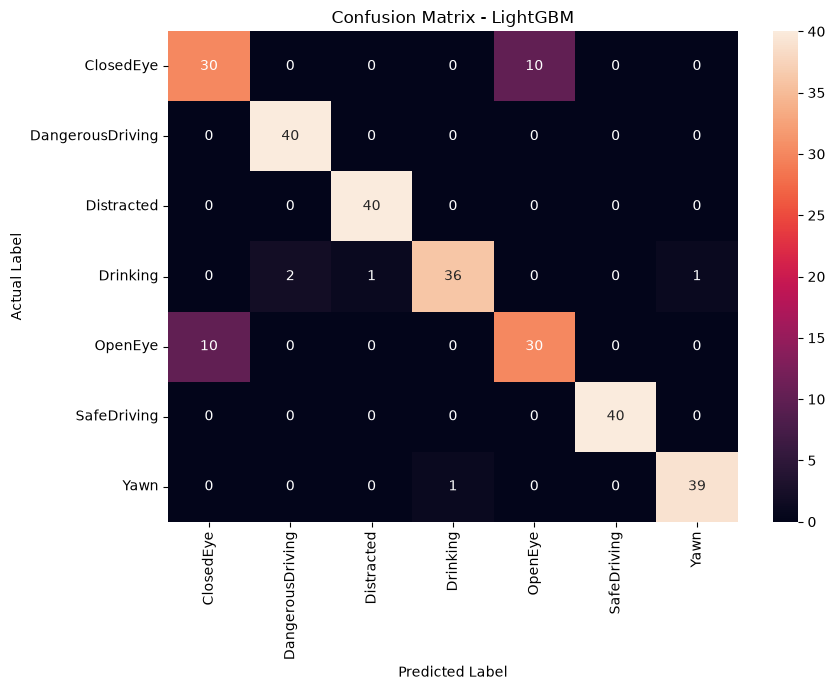

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(
    figsize=(9, 7)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.tight_layout()

plt.show()

In [20]:
OUTPUT_DIR = Path(
    "../outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [21]:
predictions = pd.DataFrame({

    "actual": encoder.inverse_transform(y_test),

    "predicted": encoder.inverse_transform(y_pred)

})

predictions.to_csv(
    OUTPUT_DIR /
    "baseline_predictions.csv",
    index=False
)

In [22]:
tuned_results.to_csv(
    OUTPUT_DIR /
    "tuned_model_comparison.csv",
    index=False
)

In [23]:
pd.DataFrame(
    [final_results]
).to_csv(
    OUTPUT_DIR /
    "final_baseline_model.csv",
    index=False
)

In [24]:
import joblib
from pathlib import Path

OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    best_model,
    OUTPUT_DIR / "best_model.pkl"
)

print("✅ Best model saved")
print("Model:", type(best_model).__name__)

✅ Best model saved
Model: LGBMClassifier
